# Purpose and boundaries

ACC requested a base model that reproduces consumption prevalence, intensity and mortality, makes calibration assessable, and can be iterated with coauthors before policy modules are added. The immediate commitment is a 2012–2024 model by the end of September; the annual report needs a documented base model and papers. Other dates in [Claude's proposal](plan_trabajo_post_reunion_ACC_2026-09-17.md) are planning proposals, not newly verified ACC commitments.

This notebook implements a **working, explicitly provisional baseline**: synthetic people aged **15–65**, annual ageing, all-cause deaths, age-15 entry, exit at age 66, residual population flows, continuous survey-scale consumption and HED. All model functions are visible below. Only data files and installed packages are read; no project R script is sourced.

**Interpretation matters:** repeated ENPG cross-sections identify population distributions, not individual transition histories. We calibrate annual marginal prevalence and mean intensity, then construct histories with a stated persistence assumption. Mortality currently depends on age, sex and calendar year—not alcohol exposure. This base can describe demographic mortality and consumption together; it cannot yet estimate alcohol-dependent survival or a policy's deaths averted.

**Three distinct runs:** (1) a static-2012 comparator; (2) a model fitted through 2020, evaluated on 2022/2024 consumption and later mortality; (3) an all-wave refit with a 2025–2034 conditional scenario. The third run has no untouched holdout. Historical evaluation conditions on year-specific INE populations and HMD mortality inputs, so it is not a fully prospective forecast.

**Observed execution result (default configuration):** all 13 code cells complete, but the held-out prevalence comparison fails: RMSE **10.26 percentage points**, mean overprediction **9.75 points**, and **0/16** cells inside working 95% survey intervals. Intensity RMSE is **1.08 g/day**. Holding 2012 prevalence/intensity means fixed performs better on those two outcomes. This is an executable calibrated candidate, not a validated reproduction of 2012–2024. Recompute these conclusions if inputs or settings change.

**Read first:** the plan audit, data exclusions, validation tables and final interpretation. Engineering checks must pass. Good predictive performance is an empirical outcome, not an assertion that code can force.

## 1. Review of the proposed plan

| Proposal | Audit | Implementation here |
| :--- | :--- | :--- |
| Copy the existing ordinal pipeline and use alpha=0.5 annually | Row-normalized square roots of probabilities are not matrix annualization. For a symmetric 0.90/0.10 matrix, the proposed operation gives 0.75/0.25; two steps give 0.625 on the diagonal, not 0.90. | Specify a genuinely annual stochastic process. Persistence is exposed and tested, not estimated from invented longitudinal records. |
| Train pseudo-pairs through 2022 and use nearest-wave entrants | Those choices consume holdout outcomes. The existing calibration script also has syntax errors, global-object references and incompatible function definitions. | Freeze prevalence, intensity, Gamma shape, HED, entry-history proportions and mortality scaling at 2020 for validation. Functions are written inline with explicit inputs. |
| Age category advances one step each year | That can move someone from 15–29 to 30–44 in one year. | Increment single-year age; derive categories afterward. |
| ENPG covers 15–64 | The actual retained data reach age 65. | Model 15–65 explicitly and end follow-up at 66. No claim of national 15+ or lifetime benefits. |
| Use the design cache as a complete baseline | It lacks consumption variables; 2018/2020 raw age/sex fields are missing. | Use ENPG_BINGE with IDs and ages, joined to design fields by year and ID. |
| Former drinking means at least one year abstinent | The active exposure pipeline uses last drink **more than 30 days ago**, including the >1-year code. | Preserve that recency definition; distinguish it from true lifetime history and from source-specific former-drinker RR definitions. |
| WHO correction leaves consumption prevalence unchanged | A positive-volume scale factor preserves current-drinking status but may change risk categories. The inherited denominator is conditional on finite volume and omits non-drinkers with missing volume. | Use raw survey-scale g/day; audit the inherited adjustment separately. No unsupported APC correction is applied. |
| Mortality equals AAF plus a residual component | AAF is a fraction of population burden, not a person's probability of death. Life expectancy ex is also not a death probability. | Use HMD qx for all-cause mortality, calibrate only training-period sex multipliers, and compare with DEIS. |
| INE population matches or replicated MicSim imply validation | Reconciled stocks match by construction. A second engine does not establish epidemiological validity. Independent scalar −log(1−p) conversions are not an equivalent multistate model. | Keep one annual engine; test invariants, held-out performance and structural sensitivity. |
| Education, beverage shares and policies from the outset | They add unparameterized dimensions before the base is assessed. | Defer them explicitly; no empty placeholder columns or unused policy classes. |

The user explicitly requested a notebook, superseding the proposal's separate-script layout and “no notebooks” instruction. Existing `expand_pif*`, RR/AAF/PIF engines and the source plan are not edited. Path resolution uses `here::i_am()`/`here::here()` because this checkout lacks the prescribed marker/helpers. The canonical [handoff](codex_handoff_adam_rr_full_override_caveman.md) remains authoritative for current RR provenance and the unresolved cached-YPLL discrepancy.

## 2. Reference architecture and Chilean adaptation

Kilian C, Buckley C, Lemp JM, Kou X, Kerr WC, Mulia N, Purshouse RC, Rehm J, Probst C. *Targeting alcohol use in high-risk population groups: a US microsimulation study of beverage-specific pricing policies*. Lancet Public Health, 2025. [DOI 10.1016/S2468-2667(25)00165-3](https://doi.org/10.1016/S2468-2667(25)00165-3); [local supplement](../_bib/local/mmc1.pdf), printed pp. 4–5, 8, 15, 17–19 and 22.

| Element | Reference implementation | Local baseline |
| :--- | :--- | :--- |
| Entity and initialization | Synthetic US adults, census/BRFSS constraints | Synthetic Chilean people; exact-age/sex INE stocks; ENPG-derived exposure distributions |
| Schedule | Record → mortality → education → alcohol → ageing → entry/migration | Record January exposure → mortality → age/exit → reconcile next January stocks → next-year exposure at attained age |
| Stochasticity | Individual uniform event draws and exposure sampling | Individual mortality uniforms and Gaussian latent exposure ranks; fixed seeds and repeated runs |
| Transitions | Rank-matched pseudo-longitudinal observations and ordinal model | Annual calibrated margins plus an explicit Gaussian persistence assumption; not a copied or estimated SIMAH transition model |
| Intensity | Bounded within-category distributions; redraw when category changes | Zero/Gamma mixture among current drinkers; update continuous exposure annually, then derive categories |
| History | Former status reassigned among non-drinkers | Never/ever history is irreversible for each surviving synthetic person; observed recency and simulated lifetime history remain distinct |
| Mortality | Cause-specific RR-normalized baseline rates and other causes | All-cause HMD input, training-only scaling and DEIS concordance; no cause-specific alcohol link yet |
| Demography | Age entrants and migration | Age-15 entrants, age-66 exits and labeled residual stock additions/removals |

The timing adaptation evaluates next-year exposure at the attained age. It does not import US ages, migration, education, beverage parameters or YLL conventions. The published supplement describes rank-matching assumptions; it is not evidence that Chilean individual transitions have been identified. The vendored code also contains apparent indicator-recoding inconsistencies, another reason to reuse the architecture rather than source it wholesale.

**Provenance:** SIMAH release 0.1.1 (internal package version `0.0.0.9000`), cited by DOI and not vendored in this repository: [Zenodo 10.5281/zenodo.15641639](https://doi.org/10.5281/zenodo.15641639). Upstream repository URL and commit could not be verified in this session. No reference code is imported into the engine. The reference is recorded by DOI in the output provenance table (no file hash).

For multistate annualization issues, see [Chhatwal et al. 2016](https://pubmed.ncbi.nlm.nih.gov/27369084/). Clipping a matrix root's negative entries is not a justified annual transition model.

## 3. Configuration and outputs

The default run uses 25,000 synthetic people and five Monte Carlo repeats for historical validation. Population expansion weights are constant within a run. Increase population size and repeats only after examining the reported Monte Carlo variation. The fixed 15–65 age support and 2012–2034 input window are asserted rather than silently generalized.

The persistence value 0.8 is a **working structural assumption**, not an estimate. Sensitivity runs use 0 and 0.95. No automatic package installation, workspace clearing or raw-data export occurs. Re-running with export enabled replaces only the named aggregate outputs in this notebook's output directory.

In [1]:
#| label: ms-setup
#| results: "hold"
.t0 <- Sys.time()
ms_packages <- base::c("here", "haven", "survey", "dplyr", "readxl", "arrow", "knitr", "IRdisplay", "ggplot2")
ms_missing <- ms_packages[!base::vapply(ms_packages, base::requireNamespace, base::logical(1), quietly = TRUE)]
if (base::length(ms_missing)) base::stop("Missing packages: ", base::paste(ms_missing, collapse = ", "))
base::suppressMessages(here::i_am("__andres_control/microsim_base_ACC_2012_2024.ipynb"))
source(here::here("_tools", "acc_data.R"))
ms_cfg <- base::list(start_year = 2012L, train_end = 2020L, observed_end = 2024L, end_year = 2034L,
  min_age = 15L, max_age = 65L, n_sim = 25000L, seeds = 20260917L + 0:4, rho = 0.8,
  export = TRUE, output_dir = "__andres_control/microsim_base_outputs")
base::stopifnot(ms_cfg$min_age == 15L, ms_cfg$max_age == 65L, ms_cfg$start_year == 2012L,
  ms_cfg$train_end == 2020L, ms_cfg$observed_end == 2024L, ms_cfg$end_year == 2034L,
  base::length(ms_cfg$seeds) >= 2L)
ms_table <- function(x, caption = NULL) {
  IRdisplay::display_html(base::as.character(knitr::kable(x, format = "html", digits = 4,
    row.names = FALSE, caption = caption)))
}
base::message(base::sprintf("ms-setup elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))


ms-setup elapsed minutes: 0.02



## 4. Survey inputs, measurement and design targets

The first input contains seven repeated cross-sections with IDs and exact ages. The design cache supplies weights and design fields. We retain unknown drinking status and missing intensity in the audit rather than treating them as abstention. Current drinking is past-30-day drinking; intensity and HED targets use observed responses among current drinkers. Twelve current drinkers report zero reconstructed volume and remain in the zero/Gamma mixture.

The quantity formula follows the established 12-g drink convention and AUDIT quantity midpoints. Episode counts can exceed drinking days: the inherited `max(days−episodes,0)` rule remains a measurement approximation. Different HED questionnaire thresholds across waves are not solved by renaming an indicator.

**Survey precision:** 2016 block IDs include commune/district/zone/block; 2024 uses the supplied ESTRATO field. Earlier waves use region as a proxy stratum. In 2020 there is no validated PSU, so weights-only standard errors are working values, not validated complex-design uncertainty. Singleton-domain adjustments are counted. Interval coverage is descriptive, excludes 2020, and must not be interpreted as fully verified design coverage for every wave. Complete-case intensity/HED estimates require a missingness assumption; no unobserved values are silently imputed.

In [2]:
#| label: ms-survey-inputs
#| results: "hold"
.t0 <- Sys.time()
# Keep IDs and exact ages; the saved PIF exposure cache discards both.
# Resolve a label to a readable path: "bundle.tar.xz.enc::member" or "bundle.tar.xz.enc" -> decrypted file (acc_data()); anything else -> repo-relative path.
ms_path <- function(label) base::vapply(label, function(z) {
  if (base::grepl("::", z, fixed = TRUE)) {
    p <- base::strsplit(z, "::", fixed = TRUE)[[1L]]
    acc_data(p[[1L]], p[[2L]])
  } else if (base::grepl("\\.tar\\.xz\\.enc$", z)) {
    acc_data(z)
  } else {
    here::here(z)
  }
}, base::character(1), USE.NAMES = FALSE)
ms_exposure_files <- base::c(
  binge = "_enpg/enpg.tar.xz.enc::derived/ENPG_BINGE.RDS",
  design = "_enpg/enpg.tar.xz.enc::derived/enpg_design_waves_2012_2024_list.RDS",
  psu2016 = "_enpg/enpg.tar.xz.enc::base ENPG 2016 publico general.dta")
base::stopifnot(base::all(base::file.exists(ms_path(ms_exposure_files))),
  base::all(base::file.info(ms_path(ms_exposure_files))$size > 2))
ms_exposure_provenance <- base::data.frame(input = base::names(ms_exposure_files),
  file = base::unname(ms_exposure_files), bytes = base::file.info(ms_path(ms_exposure_files))$size,
  md5 = base::unname(tools::md5sum(ms_path(ms_exposure_files))))
ms_raw <- base::readRDS(ms_path(ms_exposure_files[["binge"]]))
ms_design_cache <- base::readRDS(ms_path(ms_exposure_files[["design"]]))
ms_wave_years <- base::seq(2012L, 2024L, 2L)
base::stopifnot(base::all(base::c("id", "year", "sexo", "edad", "exp", "oh1", "oh2", "oh3", "db", "audit2") %in% base::names(ms_raw)),
  base::setequal(ms_raw$year, ms_wave_years),
  base::setequal(base::names(ms_design_cache$waves), base::as.character(ms_wave_years)),
  !base::anyDuplicated(ms_raw[base::c("year", "id")]))
# The short 2016 key merges distinct blocks; retain district and zone as well.
ms_psu16 <- base::as.data.frame(haven::read_dta(ms_path(ms_exposure_files[["psu2016"]]),
  col_select = base::c("idencuesta", "comuna", "distrito", "zona", "manzana")))
base::stopifnot(!base::anyDuplicated(ms_psu16$idencuesta), base::all(stats::complete.cases(ms_psu16)))
ms_design_lookup <- base::do.call(base::rbind, base::lapply(ms_wave_years, function(ms_y) {
  ms_d <- ms_design_cache$waves[[base::as.character(ms_y)]]
  base::stopifnot(base::all(base::c("year", "id_join", "weight", "region", "commune", "psu") %in% base::names(ms_d)),
    !base::anyDuplicated(ms_d$id_join))
  ms_psu <- if (ms_y == 2020L) base::rep(NA_character_, base::nrow(ms_d)) else
    base::paste(ms_d$commune, ms_d$psu, sep = "|")
  if (ms_y == 2016L) {
    ms_j <- base::match(ms_d$id_join, base::as.character(ms_psu16$idencuesta))
    base::stopifnot(!base::anyNA(ms_j))
    ms_psu <- base::do.call(base::paste, base::c(ms_psu16[ms_j,
      base::c("comuna", "distrito", "zona", "manzana")], sep = "|"))
  }
  if (ms_y != 2020L) base::stopifnot(!base::anyNA(ms_d$psu))
  if (ms_y == 2024L) base::stopifnot("ESTRATO" %in% base::names(ms_d))
  base::data.frame(year = ms_y, id = ms_d$id_join, weight = ms_d$weight, psu = ms_psu,
    stratum = base::as.character(if (ms_y == 2024L) ms_d$ESTRATO else ms_d$region),
    design_status = if (ms_y == 2020L) "Weights only; no validated clustering SE" else
      if (ms_y == 2024L) "PSU + supplied ESTRATO" else "PSU + region proxy strata")
}))
base::stopifnot(!base::anyDuplicated(ms_design_lookup[base::c("year", "id")]))
ms_match <- base::match(base::paste(ms_raw$year, ms_raw$id, sep = "|"),
  base::paste(ms_design_lookup$year, ms_design_lookup$id, sep = "|"))
base::stopifnot(!base::anyNA(ms_match))
ms_d <- ms_design_lookup[ms_match, ]
base::stopifnot(base::all(base::is.finite(ms_d$weight) & ms_d$weight > 0),
  !base::anyNA(ms_d$stratum), base::all(ms_raw$sexo %in% base::c("Hombre", "Mujer")),
  base::all(base::is.finite(ms_raw$edad)))
# Use the unrounded public design weight (2014 exp contains rounded weights).
ms_enpg_all <- base::data.frame(id = base::as.character(ms_raw$id), year = base::as.integer(ms_raw$year),
  sex = base::ifelse(ms_raw$sexo == "Hombre", "male", "female"), age = base::as.integer(ms_raw$edad),
  weight = ms_d$weight, psu = ms_d$psu, stratum = ms_d$stratum, design_status = ms_d$design_status)
ms_ever <- base::as.character(ms_raw$oh1)
ms_recency <- base::as.character(ms_raw$oh2)
ms_enpg_all$status <- base::ifelse(ms_ever == "No" & base::is.na(ms_recency), "never",
  base::ifelse(ms_ever == "Si" & ms_recency == "30 dias", "current",
    base::ifelse(ms_ever == "Si" & ms_recency %in% base::c(">30", ">1 a\u00f1o"), "former", NA_character_)))
ms_enpg_all$status[base::is.na(ms_enpg_all$status)] <- "unknown"
ms_enpg_all$current <- base::ifelse(ms_enpg_all$status == "unknown", NA_real_,
  base::as.numeric(ms_enpg_all$status == "current"))
ms_enpg_all$ever <- base::ifelse(ms_ever == "Si", TRUE, base::ifelse(ms_ever == "No", FALSE, NA))
ms_days <- base::as.numeric(ms_raw$oh3)
ms_days[!base::is.finite(ms_days) | ms_days < 0 | ms_days > 30] <- NA_real_
ms_episodes <- base::as.numeric(ms_raw$db)
ms_episodes[!base::is.finite(ms_episodes) | ms_episodes < 0 | ms_episodes >= 88] <- NA_real_
ms_midpoints <- base::c("0-2" = 1, "3-4" = 3.5, "5-6" = 5.5, "7-8" = 7.5, "9 o mas" = 9)
ms_drinks <- base::unname(ms_midpoints[base::as.character(ms_raw$audit2)])
# Inherit the 12-g drink convention; this survey scale has no WHO multiplier.
# Episode counts can exceed drinking days; pmax preserves the existing approximation.
ms_enpg_all$gpd_survey <- (base::pmax(ms_days - ms_episodes, 0) * ms_drinks +
  ms_episodes * base::ifelse(ms_enpg_all$sex == "male", 5, 4)) * 12 / 30
ms_enpg_all$hed <- base::as.numeric(ms_episodes > 0)
ms_noncurrent <- ms_enpg_all$status %in% base::c("never", "former")
ms_enpg_all$gpd_survey[ms_noncurrent] <- 0
ms_enpg_all$hed[ms_noncurrent] <- 0
ms_enpg_all$gpd_survey[ms_enpg_all$status == "unknown"] <- NA_real_
ms_enpg_all$hed[ms_enpg_all$status == "unknown"] <- NA_real_
ms_enpg_all$age_group <- base::findInterval(ms_enpg_all$age, base::c(15, 30, 45, 60))
ms_enpg_all$in_domain <- ms_enpg_all$age >= ms_cfg$min_age & ms_enpg_all$age <= ms_cfg$max_age
ms_enpg <- ms_enpg_all[ms_enpg_all$in_domain, ]
base::stopifnot(base::all(ms_enpg$age_group %in% 1:4),
  base::all(ms_enpg$gpd_survey[ms_enpg$status %in% base::c("never", "former")] == 0))
ms_data_audit <- base::do.call(base::rbind, base::lapply(ms_wave_years, function(ms_y) {
  ms_x <- ms_enpg[ms_enpg$year == ms_y, ]
  ms_c <- ms_x$status == "current"
  base::data.frame(year = ms_y, raw_n = base::sum(ms_raw$year == ms_y), domain_n = base::nrow(ms_x),
    never_n = base::sum(ms_x$status == "never"), former_n = base::sum(ms_x$status == "former"),
    current_n = base::sum(ms_c), unknown_status = base::sum(ms_x$status == "unknown"),
    current_gpd_missing = base::sum(ms_c & base::is.na(ms_x$gpd_survey)),
    current_gpd_zero = base::sum(ms_c & ms_x$gpd_survey == 0, na.rm = TRUE),
    current_hed_missing = base::sum(ms_c & base::is.na(ms_x$hed)),
    design_status = base::unique(ms_x$design_status))
}))
# Form the full wave design before subsetting domains so that survey design information is retained.
# ponytail: region is a proxy stratum before 2024; replace when verified full design variables are available.
ms_build_targets <- function() {
  ms_old_options <- base::options(survey.lonely.psu = "adjust", survey.adjust.domain.lonely = TRUE)
  base::on.exit(base::options(ms_old_options), add = TRUE)
  base::do.call(base::rbind, base::lapply(ms_wave_years, function(ms_y) {
    ms_wave <- ms_enpg_all[ms_enpg_all$year == ms_y, ]
    ms_design <- if (ms_y == 2020L) survey::svydesign(ids = ~1, weights = ~weight, data = ms_wave) else
      survey::svydesign(ids = ~psu, strata = ~stratum, weights = ~weight, data = ms_wave, nest = TRUE)
    ms_grid <- base::expand.grid(sex = base::c("male", "female"), age_group = 1:4, stringsAsFactors = FALSE)
    base::do.call(base::rbind, base::lapply(base::seq_len(base::nrow(ms_grid)), function(ms_i) {
      ms_select <- ms_wave$in_domain & ms_wave$sex == ms_grid$sex[ms_i] & ms_wave$age_group == ms_grid$age_group[ms_i]
      ms_cell <- ms_design[ms_select, ]
      ms_v <- ms_cell$variables
      ms_current <- !base::is.na(ms_v$current) & ms_v$current == 1
      ms_lonely <- 0L
      ms_estimates <- base::lapply(base::c("current", "gpd_survey", "hed"), function(ms_variable) {
        ms_part <- if (ms_variable == "current") ms_cell else ms_cell[ms_current, ]
        # Report known domain singleton adjustments as a count instead of repeated warnings.
        ms_est <- base::withCallingHandlers(
          survey::svymean(stats::reformulate(ms_variable), ms_part, na.rm = TRUE), warning = function(ms_warning) {
            if (base::grepl("has only one PSU at stage 1", base::conditionMessage(ms_warning), fixed = TRUE)) {
              ms_lonely <<- ms_lonely + 1L
              base::invokeRestart("muffleWarning")
            }
          })
        base::c(mean = base::as.numeric(stats::coef(ms_est)), se = base::as.numeric(survey::SE(ms_est)))
      })
      ms_w <- ms_v$weight[!base::is.na(ms_v$current)]
      base::data.frame(year = ms_y, sex = ms_grid$sex[ms_i], age_group = ms_grid$age_group[ms_i],
        n = base::nrow(ms_v), n_current_observed = base::sum(!base::is.na(ms_v$current)),
        n_current = base::sum(ms_current), n_gpd = base::sum(ms_current & base::is.finite(ms_v$gpd_survey)),
        n_hed = base::sum(ms_current & !base::is.na(ms_v$hed)), n_eff = base::sum(ms_w)^2 / base::sum(ms_w^2),
        current_mean = ms_estimates[[1]][["mean"]], current_se = ms_estimates[[1]][["se"]],
        gpd_mean = ms_estimates[[2]][["mean"]], gpd_se = ms_estimates[[2]][["se"]],
        hed_mean = ms_estimates[[3]][["mean"]], hed_se = ms_estimates[[3]][["se"]],
        design_status = base::unique(ms_v$design_status), lonely_psu_adjustment_warnings = ms_lonely)
    }))
  }))
}
ms_targets <- ms_build_targets()
base::stopifnot(base::nrow(ms_targets) == 56L, !base::anyDuplicated(ms_targets[base::c("year", "sex", "age_group")]),
  base::all(base::is.finite(base::as.matrix(ms_targets[base::c("current_mean", "current_se", "gpd_mean", "gpd_se", "hed_mean", "hed_se")]))),
  base::all(ms_targets$current_mean > 0 & ms_targets$current_mean < 1), base::all(ms_targets$gpd_mean > 0),
  base::all(ms_targets$hed_mean >= 0 & ms_targets$hed_mean <= 1))
ms_table(ms_exposure_provenance)
ms_table(ms_data_audit)
ms_table(ms_targets[base::seq_len(8), ])
base::message(base::sprintf("Exposure inputs and design targets elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))


input,file,bytes,md5
binge,ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e/ENPG_BINGE.RDS,2500055,1ed65c4f6c45ee71bc1e76dbbbb268f0
design,Sex-and-age-differences-in-alcohol-attributable-mortality-in-Chile-between-2008-and-2022-main/Raw data/enpg_design_waves_2012_2024_list.RDS,1232168,0b5e68e3a3f6a2dd827eecca8c665072
psu2016,Sex-and-age-differences-in-alcohol-attributable-mortality-in-Chile-between-2008-and-2022-main/Raw data/base ENPG 2016 publico general.dta,16944685,00a6db4c5be75432cd2a49c94eb65a2a


year,raw_n,domain_n,never_n,former_n,current_n,unknown_status,current_gpd_missing,current_gpd_zero,current_hed_missing,design_status
2012,17154,16322,3989,5358,6893,82,312,0,264,PSU + region proxy strata
2014,20113,19326,4089,6202,8904,131,836,12,757,PSU + region proxy strata
2016,19147,18354,4150,6703,7304,197,485,0,464,PSU + region proxy strata
2018,19427,18734,4260,6648,7484,342,757,0,553,PSU + region proxy strata
2020,16662,16114,3512,5953,6512,137,563,0,527,Weights only; no validated clustering SE
2022,17454,17023,4260,6656,5999,108,383,0,350,PSU + region proxy strata
2024,18668,18231,5601,6963,5528,139,408,0,348,PSU + supplied ESTRATO


year,sex,age_group,n,n_current_observed,n_current,n_gpd,n_hed,n_eff,current_mean,current_se,gpd_mean,gpd_se,hed_mean,hed_se,design_status,lonely_psu_adjustment_warnings
2012,male,1,2334,2315,1202,1140,1155,679.8410,0.5156,0.0197,7.6294,0.3681,0.7129,0.0266,PSU + region proxy strata,0
2012,female,1,2623,2605,973,933,941,658.2817,0.3636,0.0180,4.8748,0.5412,0.5468,0.0275,PSU + region proxy strata,0
2012,male,2,2193,2185,1275,1228,1235,807.3792,0.5833,0.0183,6.3804,0.3192,0.5819,0.0244,PSU + region proxy strata,0
2012,female,2,2816,2803,1001,958,961,777.8630,0.3602,0.0172,2.9862,0.2289,0.4167,0.0281,PSU + region proxy strata,0
2012,male,3,1976,1968,1033,966,974,636.9949,0.5187,0.0218,7.8960,0.5295,0.5991,0.0290,PSU + region proxy strata,0
2012,female,3,2636,2627,835,805,811,683.2349,0.3321,0.0182,3.1380,0.5387,0.3607,0.0322,PSU + region proxy strata,0
2012,male,4,654,650,296,281,281,215.9685,0.4422,0.0331,5.9725,0.5813,0.4247,0.0459,PSU + region proxy strata,0
2012,female,4,1090,1087,278,270,271,374.8775,0.2400,0.0204,2.2515,0.2695,0.2097,0.0346,PSU + region proxy strata,0


Exposure inputs and design targets elapsed minutes: 0.09



### The inherited APC correction is not used as a population target

The following audit reads the existing saved exposure cache and reports the denominator actually available for its corrected-volume means. It does not change that cache. Raw survey g/day and externally adjusted risk exposure are different scales. An APC correction would require a compatible age/frame denominator, recorded/unrecorded alcohol definition and year-specific series; the WHO 15+ target cannot simply be imposed on a 15–65 model. Multiplication of intensity must not redefine observed current-drinking prevalence.

In [3]:
#| label: ms-apc-audit
#| results: "hold"
.t0 <- Sys.time()
ms_legacy <- base::readRDS(here::here("__andres_control", "data_binge_sensitivity.rds"))
ms_apc_audit <- ms_legacy |>
  dplyr::group_by(year) |>
  dplyr::summarise(rows = dplyr::n(), volume_observed = base::sum(base::is.finite(volajohdia)),
    noncurrent_rows = base::sum(cvolaj %in% base::c("ltabs", "fd")),
    noncurrent_missing_volume = base::sum(cvolaj %in% base::c("ltabs", "fd") & !base::is.finite(volajohdia)),
    corrected_mean_among_finite = stats::weighted.mean(volajohdia[base::is.finite(volajohdia)],
      exp[base::is.finite(volajohdia)]), .groups = "drop")
ms_table(ms_apc_audit, "Legacy corrected-volume denominator audit; no APC correction applied here")
base::message(base::sprintf("ms-apc-audit elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))


year,rows,volume_observed,noncurrent_rows,noncurrent_missing_volume,corrected_mean_among_finite
2012,16172,6581,9347,9347,13.8572
2014,19123,8068,10291,10291,14.1553
2016,18121,6819,10853,10853,12.2491
2018,18051,6727,10908,10908,11.7780
2020,15771,5949,9465,9465,13.6774
2022,16763,5616,10916,10916,13.6878
2024,17944,5120,12564,12564,13.6764


ms-apc-audit elapsed minutes: 0.00



## 5. Population and all-cause mortality inputs

The INE workbook contains January and June observations: selecting neither would double the population. January stocks define the annual cycle; June stocks support a separate central-rate comparison. HMD qx is an annual age-interval death probability; mx is a central death rate and ex is remaining life expectancy. No extra `1−exp(−qx)` transformation is applied.

DEIS 2024 records must have age measured in completed years. The current parquet also contains 2025/2026 records, which are excluded from the historical target. HMD and DEIS share vital-registration ancestry; their agreement is concordance, not independent external validation. January integer age is held fixed during the death step, whereas DEIS records age at death. That approximation and source-vintage differences can produce discrepancies even with correct code.

In [ ]:
#| label: ms-demography-inputs
#| results: "hold"
.t0 <- base::Sys.time()
# January stocks drive population accounting; June stocks approximate annual exposure.
# The full INE workbook contains BOTH dates despite its sheet name ending in 0101.
# DEIS 2024+ weekly file: newest version by the DDMMYYYY in its name (ACC_DEIS_VERSION pins one), the same rule as acc_deis().
ms_deis_enc <- if (base::nzchar(base::Sys.getenv("ACC_DEIS_VERSION"))) {
  base::sprintf("DEFUNCIONES_FUENTE_DEIS_2024_2026_%s.tar.xz.enc", base::Sys.getenv("ACC_DEIS_VERSION"))
} else {
  base::basename(acc_latest(base::file.path(acc_root(), "_deis")))
}
ms_deis_date <- base::format(base::as.Date(base::sub(".*_([0-9]{8})\\.tar\\.xz\\.enc$", "\\1", ms_deis_enc), "%d%m%Y"), "%Y-%m-%d")
ms_demography_files <- base::c(
  population = "__andres_control/ine_proyecciones_rebuild/ine_basedatos.xlsx",
  hmd_male = "__andres_control/ine_proyecciones_rebuild/mltper_1x1.txt",
  hmd_female = "__andres_control/ine_proyecciones_rebuild/fltper_1x1.txt",
  deaths_2012_2023 = "_deis/DEFUNCIONES_DEIS_2012_2023_15plus.tar.xz.enc",
  deaths_2024 = base::file.path("_deis", ms_deis_enc)
)
base::stopifnot(base::all(base::file.exists(ms_path(ms_demography_files))))
.ms_pop <- readxl::read_xlsx(ms_path(ms_demography_files[["population"]]), sheet = "BBDD_EEPP-2024_0101")
base::stopifnot(base::identical(base::names(.ms_pop), base::c("NIVEL", "SEXO", "FECHA", "EDAD", "POBLACION")),
  base::setequal(base::unique(.ms_pop$SEXO), base::c("H", "M")), base::length(base::unique(.ms_pop$NIVEL)) == 1L)
.ms_date <- base::as.Date(.ms_pop$FECHA, format = "%d/%m/%Y")
base::stopifnot(!base::anyNA(.ms_date))
.ms_pop <- base::data.frame(year = base::as.integer(base::format(.ms_date, "%Y")),
  sex = base::ifelse(.ms_pop$SEXO == "H", "male", "female"), age = base::as.integer(.ms_pop$EDAD),
  date = base::format(.ms_date, "%m-%d"), population = .ms_pop$POBLACION)
.ms_pop <- .ms_pop[.ms_pop$year %in% 2012:2034 & .ms_pop$age %in% 15:65, ]
base::stopifnot(base::setequal(base::unique(.ms_pop$date), base::c("01-01", "06-30")),
  base::all(base::is.finite(.ms_pop$population) & .ms_pop$population > 0),
  !base::anyDuplicated(.ms_pop[base::c("year", "sex", "age", "date")]))
.ms_keys <- base::c("year", "sex", "age")
.ms_jan <- .ms_pop[.ms_pop$date == "01-01", base::c(.ms_keys, "population")]
.ms_mid <- .ms_pop[.ms_pop$date == "06-30", base::c(.ms_keys, "population")]
base::names(.ms_jan)[4L] <- "pop_jan"
base::names(.ms_mid)[4L] <- "pop_mid"
ms_population <- base::merge(.ms_jan, .ms_mid, by = .ms_keys, all = TRUE)
base::stopifnot(base::nrow(ms_population) == 23L * 2L * 51L, !base::anyNA(ms_population),
  !base::anyDuplicated(ms_population[.ms_keys]))
# Keep the published qx probability AND mx central rate; ex is not a death probability.
# HMD dx and lx describe a synthetic life-table cohort, not observed DEIS death counts.
.ms_hmd <- base::lapply(base::c("male", "female"), function(sx) {
  z <- utils::read.table(ms_path(ms_demography_files[[base::paste0("hmd_", sx)]]),
    header = TRUE, skip = 2L, stringsAsFactors = FALSE)
  base::stopifnot(base::identical(base::names(z), base::c("Year", "Age", "mx", "qx", "ax", "lx", "dx", "Lx", "Tx", "ex")))
  z <- z[z$Year %in% 2012:2024 & z$Age %in% base::as.character(15:65), ]
  base::data.frame(year = base::as.integer(z$Year), sex = sx,
    age = base::as.integer(z$Age), qx = z$qx, mx = z$mx)
})
.ms_hmd <- base::do.call(base::rbind, .ms_hmd)
base::stopifnot(base::nrow(.ms_hmd) == 13L * 2L * 51L, !base::anyNA(.ms_hmd),
  !base::anyDuplicated(.ms_hmd[.ms_keys]), base::all(.ms_hmd$qx >= 0 & .ms_hmd$qx < 1),
  base::all(base::is.finite(.ms_hmd$mx) & .ms_hmd$mx >= 0))
# Read only the demographic columns from the existing DEIS parquet inputs.
.ms_old <- base::as.data.frame(arrow::read_parquet(ms_path(ms_demography_files[["deaths_2012_2023"]]),
  col_select = base::c("year", "gender", "age")))
base::stopifnot(base::identical(base::names(.ms_old), base::c("year", "gender", "age")))
.ms_old <- .ms_old[.ms_old$year %in% 2012:2023 & .ms_old$age %in% 15:65 &
  .ms_old$gender %in% base::c("Hombre", "Mujer"), ]
# acc_deis() returns the weekly DEIS CSV with a valid UTF-8 header ("AÑO"), so the columns can be selected by name.
.ms_new <- acc_deis()[base::c("AÑO", "SEXO_NOMBRE", "EDAD_TIPO", "EDAD_CANT")]
base::stopifnot(base::identical(base::names(.ms_new)[2:4], base::c("SEXO_NOMBRE", "EDAD_TIPO", "EDAD_CANT")))
base::names(.ms_new) <- base::c("year", "gender", "age_type", "age")
.ms_new <- base::as.data.frame(.ms_new)
base::stopifnot(base::all(.ms_new$year %in% 2024:2026))
# The file also contains provisional 2025/2026 records: they are NOT historical targets.
# age_type == 1 means completed years; infants recorded in days/hours must not enter.
.ms_new <- .ms_new[.ms_new$year == 2024L & .ms_new$age_type == 1L &
  .ms_new$age %in% 15:65 & .ms_new$gender %in% base::c("Hombre", "Mujer"), ]
base::stopifnot(base::nrow(.ms_new) > 0L, base::all(.ms_new$year == 2024L),
  base::all(.ms_new$age_type == 1L))
.ms_death_rows <- base::rbind(.ms_old, .ms_new[base::c("year", "gender", "age")])
.ms_death_rows$sex <- base::ifelse(.ms_death_rows$gender == "Hombre", "male", "female")
.ms_death_rows$deaths <- 1L
.ms_deaths <- stats::aggregate(deaths ~ year + sex + age, data = .ms_death_rows, FUN = base::sum)
# All 1,326 exact-age cells have observed deaths in these source vintages.
# A missing target fails here instead of silently becoming zero mortality.
base::stopifnot(base::nrow(.ms_deaths) == 13L * 2L * 51L,
  !base::anyDuplicated(.ms_deaths[.ms_keys]), base::all(.ms_deaths$deaths >= 0L))
ms_mortality <- base::merge(.ms_hmd, .ms_deaths, by = .ms_keys, all = TRUE)
ms_mortality <- base::merge(ms_mortality, ms_population[ms_population$year <= 2024L, ], by = .ms_keys, all = TRUE)
base::stopifnot(base::nrow(ms_mortality) == 13L * 2L * 51L, !base::anyNA(ms_mortality),
  !base::anyDuplicated(ms_mortality[.ms_keys]),
  base::sum(ms_mortality$deaths) == base::nrow(.ms_death_rows))
ms_demography_audit <- base::data.frame(
  source = base::c("INE population", "HMD period life tables", "DEIS all-cause deaths", "Historical interpretation"),
  detail = base::c("Base CPV 2024; January/June stocks; 2012-2024 estimates, 2025-2034 projections.",
    "Chile 1x1; modified 12 January 2026; observed input years 2012-2024; qx and mx retained.",
    base::sprintf("%s deaths at ages 15-65 in 2012-2024; 2024 source dated %s; %s cells.",
      base::format(base::sum(ms_mortality$deaths), big.mark = ","), ms_deis_date, base::nrow(ms_mortality)),
    "HMD/DEIS concordance is not independent external validation; population vintages and stock/exposure definitions differ.")
)
ms_table(ms_demography_audit, caption = "Demographic inputs and source vintages")
ms_table(stats::aggregate(deaths ~ year + sex, data = ms_mortality, FUN = base::sum),
  caption = "Observed all-cause DEIS deaths in the modeled 15-65 age window")
base::rm(.ms_pop, .ms_date, .ms_keys, .ms_jan, .ms_mid, .ms_hmd, .ms_old, .ms_new, .ms_death_rows, .ms_deaths)
base::message(base::sprintf("demography-inputs elapsed minutes: %.2f",
  base::as.numeric(base::difftime(base::Sys.time(), .t0, units = "mins"))))

source,detail
INE population,"Base CPV 2024; January/June stocks; 2012-2024 estimates, 2025-2034 projections."
HMD period life tables,Chile 1x1; modified 12 January 2026; observed input years 2012-2024; qx and mx retained.
DEIS all-cause deaths,"401,651 deaths at ages 15-65 in 2012-2024; 2024 source dated 2026-06-09; 1326 cells."
Historical interpretation,HMD/DEIS concordance is not independent external validation; population vintages and stock/exposure definitions differ.


year,sex,deaths
2012,female,9990
2013,female,10137
2014,female,10077
2015,female,10407
2016,female,10293
2017,female,10192
2018,female,10411
2019,female,10590
2020,female,12035
2021,female,13121


demography-inputs elapsed minutes: 0.03



## 6. Calibration model and unidentified persistence

For each sex × age group, fit a linear calendar trend to the logit of current-drinking prevalence and to log mean g/day among current drinkers. Use inverse delta-method variances of the working survey estimates as calibration weights. This is a small **marginal calibration model**, not a likelihood for longitudinal transitions. Category prevalences and HED are secondary diagnostics, not independently calibrated outcomes. A static-2012 fit is the uncalibrated comparator.

Among current drinkers, retain a training-estimated point mass at zero and a positive Gamma distribution with a survey-weighted moment shape. Divide the positive-component mean by $1-p_0$ so that the mixture mean equals the calibrated current-drinker mean. HED uses a training-only weighted logistic model conditional on sex/age group and log(1+g/day). Distributional shape and tail fit remain assumptions to assess, especially before RR integration.

Individual histories use three Gaussian latent variables—current-drinking propensity, amount rank and HED propensity:

$$Z_{i,t+1}=\rho Z_{i,t}+\sqrt{1-\rho^2}\,\epsilon_{i,t+1},\qquad \epsilon\sim N(0,1).$$

Thresholding the first variable by predicted annual prevalence yields current drinking; transforming the second by the zero/Gamma inverse distribution yields intensity. This is an annual construction, so no biennial “annualization” is required. **Rho is unidentified by cross-sectional margins**; it controls synthetic persistence and materially affects never/ever histories. It is not selected using holdout performance.

All-cause mortality uses $q^*_{a,s,t}=1-(1-q_{a,s,t})^{k_s}$, with one positive hazard multiplier per sex fitted to training-period DEIS totals. This calibrates an aggregate mortality level; age/year-specific discrepancies remain visible. Calibration to those counts is not independent validation.

In [5]:
#| label: ms-calibration-functions
.t0 <- Sys.time()

# These functions calibrate marginal exposure distributions, not observed person transitions.
# Keeping calibration deterministic avoids fitting to noise from a finite microsimulation.
ms_fit <- function(last_year, trend = TRUE) {
  train <- ms_enpg[ms_enpg$year <= last_year, ]
  target <- ms_targets[ms_targets$year <= last_year, ]
  target$cell <- base::factor(base::paste(target$sex, target$age_group, sep = ":"))
  target$time <- (target$year - ms_cfg$start_year) / 10
  base::stopifnot(base::all(target$current_mean > 0 & target$current_mean < 1),
                  base::all(target$gpd_mean > 0))
  # Delta-method inverse variances are working calibration weights, not a full joint likelihood.
  target$y_current <- stats::qlogis(target$current_mean)
  target$y_amount <- base::log(target$gpd_mean)
  target$w_current <- (target$current_mean * (1 - target$current_mean) / target$current_se)^2
  target$w_amount <- (target$gpd_mean / target$gpd_se)^2
  base::stopifnot(base::all(base::is.finite(target$w_current) & target$w_current > 0),
                  base::all(base::is.finite(target$w_amount) & target$w_amount > 0))
  # An uncalibrated comparator holds the 2012 survey means constant within each cell.
  fit_data <- if (trend) target else target[target$year == ms_cfg$start_year, ]
  formula_current <- if (trend) y_current ~ 0 + cell + cell:time else y_current ~ 0 + cell
  formula_amount <- if (trend) y_amount ~ 0 + cell + cell:time else y_amount ~ 0 + cell
  prevalence <- stats::lm(formula_current, data = fit_data, weights = w_current)
  amount <- stats::lm(formula_amount, data = fit_data, weights = w_amount)

  # The Gamma shape reuses the project's survey-weighted moment estimator, now on RAW g/day.
  shape <- train |>
    dplyr::filter(current == 1, base::is.finite(gpd_survey), gpd_survey > 0) |>
    dplyr::group_by(sex, age_group) |>
    dplyr::summarise(mu = stats::weighted.mean(gpd_survey, weight),
      variance = stats::weighted.mean((gpd_survey - mu)^2, weight),
      shape = mu^2 / variance, .groups = "drop")
  zero <- train |>
    dplyr::filter(current == 1, base::is.finite(gpd_survey)) |>
    dplyr::group_by(sex, age_group) |>
    dplyr::summarise(p_zero = stats::weighted.mean(gpd_survey == 0, weight), .groups = "drop")
  former <- train |>
    dplyr::filter(current == 0, !base::is.na(ever)) |>
    dplyr::group_by(sex, age_group) |>
    dplyr::summarise(p_ever_noncurrent = stats::weighted.mean(ever, weight), .groups = "drop")
  shape <- shape |>
    dplyr::left_join(zero, by = base::c("sex", "age_group")) |>
    dplyr::left_join(former, by = base::c("sex", "age_group"))
  base::stopifnot(base::nrow(shape) == 8L, base::all(base::is.finite(shape$shape)),
                  base::all(shape$shape > 0), base::all(shape$p_zero < 1))

  # HED is conditional on current drinking and intensity; questionnaire harmonization remains a caveat.
  hed_data <- train[train$current %in% 1 & base::is.finite(train$gpd_survey) &
                     train$gpd_survey > 0 & !base::is.na(train$hed), ]
  hed_data$cell <- base::factor(base::paste(hed_data$sex, hed_data$age_group, sep = ":"))
  hed_data$w_fit <- hed_data$weight / base::mean(hed_data$weight)
  hed <- stats::glm(hed ~ 0 + cell + base::log1p(gpd_survey), data = hed_data,
                    weights = w_fit, family = stats::quasibinomial())
  base::stopifnot(hed$converged, !base::anyNA(stats::coef(hed)))

  # Calibrate one all-cause hazard multiplier per sex using TRAINING deaths only.
  death_train <- ms_mortality[ms_mortality$year <= last_year, ]
  mortality_scale <- base::vapply(base::c("female", "male"), function(s) {
    d <- death_train[death_train$sex == s, ]
    f <- function(log_scale) base::sum(d$pop_jan *
      (-base::expm1(base::log1p(-d$qx) * base::exp(log_scale)))) - base::sum(d$deaths)
    if (!trend) base::return(1)
    base::exp(stats::uniroot(f, interval = base::c(-3, 3))$root)
  }, base::numeric(1))
  base::list(prevalence = prevalence, amount = amount, shape = shape, hed = hed,
    mortality_scale = mortality_scale, last_year = last_year, trend = trend,
    training_years = base::sort(base::unique(train$year)))
}

ms_drivers <- function(model, years) {
  grid <- base::expand.grid(year = years, sex = base::c("female", "male"), age_group = 1:4,
                           stringsAsFactors = FALSE)
  grid$cell <- base::factor(base::paste(grid$sex, grid$age_group, sep = ":"),
                           levels = model$prevalence$xlevels$cell)
  # ponytail: freeze drivers after 2024; add a forecast process only with defensible future assumptions.
  # Validation extrapolates 2020-trained trends to 2024.
  grid$time <- (base::pmin(grid$year, ms_cfg$observed_end) - ms_cfg$start_year) / 10
  grid$p_current <- stats::plogis(stats::predict(model$prevalence, newdata = grid))
  grid$mu_current <- base::exp(stats::predict(model$amount, newdata = grid))
  grid <- dplyr::left_join(grid, model$shape, by = base::c("sex", "age_group"))
  grid$hed_intercept <- stats::coef(model$hed)[base::paste0("cell", base::as.character(grid$cell))]
  grid$hed_slope <- base::unname(stats::coef(model$hed)["base::log1p(gpd_survey)"])
  base::stopifnot(!base::anyNA(grid), base::all(grid$p_current > 0 & grid$p_current < 1),
                  base::all(grid$mu_current > 0))
  grid$key <- base::paste(grid$year, grid$sex, grid$age_group, sep = ":")
  grid
}
base::message(base::sprintf("ms-calibration-functions elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))


ms-calibration-functions elapsed minutes: 0.00



## 7. Annual person-level engine

Each January records consumption and the age/sex population. Deaths occur once and remove a person permanently. Survivors age one year; people reaching 66 leave the modeled window. New age-15 entrants and residual additions/removals reconcile INE stocks. Residual flows are accounting quantities, absorbing migration, mortality noise, vintage differences and rounding; they are not observed migration estimates. Stock agreement is therefore an accounting check, not demographic prediction validation.

Next-year exposure is generated at attained age. The ever-drank flag cannot revert for a surviving synthetic ID. The displayed former state means ever drank but not current in the past 30 days. These synthetic lifetime histories are not validated by the cross-sectional margins. Categories are derived after continuous exposure using contiguous sex-specific cutoffs; the high category includes all values above the upper cutoff, including the old cat4 range.

Death probabilities are independent of alcohol in this version. Same-seed persistence sensitivities should therefore leave demographic deaths unchanged. The last flow row ends after terminal-year deaths; all earlier end counts refer to next January.

In [6]:
#| label: ms-annual-engine
.t0 <- Sys.time()

ms_age_group <- function(age) base::findInterval(age, base::c(15, 30, 45, 60))

ms_new_people <- function(sex, age, n, first_id) {
  # IDs never repeat; latent variables encode explicit annual persistence, not observed histories.
  base::data.frame(id = first_id + base::seq_len(n), sex = sex, age = age,
    z_current = stats::rnorm(n), z_amount = stats::rnorm(n), z_hed = stats::rnorm(n),
    ever = base::rep(NA, n), stringsAsFactors = FALSE)
}

ms_exposure <- function(pop, year, drivers) {
  pop$age_group <- ms_age_group(pop$age)
  k <- base::match(base::paste(year, pop$sex, pop$age_group, sep = ":"), drivers$key)
  base::stopifnot(!base::anyNA(k))
  d <- drivers[k, ]
  pop$current <- stats::pnorm(pop$z_current) < d$p_current
  # The mixture retains observed current drinkers reporting zero g/day.
  u <- stats::pnorm(pop$z_amount)
  positive <- pop$current & u > d$p_zero
  pop$gpd_survey <- 0
  pop$gpd_survey[positive] <- stats::qgamma(
    base::pmin(1 - 1e-12, base::pmax(1e-12,
      (u[positive] - d$p_zero[positive]) / (1 - d$p_zero[positive]))),
    shape = d$shape[positive],
    scale = d$mu_current[positive] / ((1 - d$p_zero[positive]) * d$shape[positive]))
  p_hed <- stats::plogis(d$hed_intercept + d$hed_slope * base::log1p(pop$gpd_survey))
  pop$hed <- positive & stats::pnorm(pop$z_hed) < p_hed
  fresh <- base::is.na(pop$ever)
  pop$ever[fresh] <- pop$current[fresh] |
    stats::runif(base::sum(fresh)) < d$p_ever_noncurrent[fresh]
  pop$ever <- pop$ever | pop$current
  pop$alc_status <- base::ifelse(pop$current, "current", base::ifelse(pop$ever, "former", "never"))
  low <- base::ifelse(pop$sex == "female", 20, 40)
  high <- base::ifelse(pop$sex == "female", 40, 60)
  # Derive categories AFTER continuous exposure. No gaps at 19.99/20 or 39.99/40.
  pop$alc_cat <- base::ifelse(!pop$current, "noncurrent", base::ifelse(pop$gpd_survey < low,
    "cat1", base::ifelse(pop$gpd_survey < high, "cat2", "cat3")))
  base::stopifnot(base::all(base::is.finite(pop$gpd_survey) & pop$gpd_survey >= 0),
                  !base::any(pop$hed & !pop$current), !base::any(pop$current & !pop$ever))
  pop
}

ms_simulate <- function(model, years, n_sim, seed, rho = 0.8) {
  base::stopifnot(base::length(years) > 0, base::all(base::diff(years) == 1),
                  n_sim >= 1000, rho >= 0, rho <= 1)
  base::set.seed(seed)
  drivers <- ms_drivers(model, years)
  stocks <- ms_population[ms_population$year %in% years, ]
  unit_weight <- base::sum(stocks$pop_jan[stocks$year == years[1]]) / n_sim
  stocks$n_target <- base::as.integer(base::round(stocks$pop_jan / unit_weight))
  base::stopifnot(base::all(stocks$n_target > 0))
  initial <- stocks[stocks$year == years[1], ]
  ids <- base::c(0L, base::cumsum(initial$n_target))
  pop <- dplyr::bind_rows(base::lapply(base::seq_len(base::nrow(initial)), function(i)
    ms_new_people(initial$sex[i], initial$age[i], initial$n_target[i], ids[i])))
  last_id <- base::max(pop$id)
  pop <- ms_exposure(pop, years[1], drivers)
  summaries <- deaths_out <- flows <- histories <- base::vector("list", base::length(years))
  trace_ids <- utils::head(pop$id, 12)
  mortality <- ms_mortality
  mortality$key <- base::paste(mortality$year, mortality$sex, mortality$age, sep = ":")

  for (i in base::seq_along(years)) {
    year <- years[i]
    start_n <- base::nrow(pop)
    # A population record describes the beginning of the calendar year, before that year's deaths.
    summaries[[i]] <- pop |>
      dplyr::group_by(sex, age_group) |>
      dplyr::summarise(n = dplyr::n(), current_mean = base::mean(current),
        gpd_mean = base::mean(gpd_survey[current]), gpd_population = base::mean(gpd_survey),
        hed_mean = base::mean(hed[current]), never = base::mean(!ever),
        former = base::mean(ever & !current),
        cat1 = base::mean(alc_cat == "cat1"), cat2 = base::mean(alc_cat == "cat2"),
        cat3 = base::mean(alc_cat == "cat3"), .groups = "drop") |>
      dplyr::mutate(year = year, seed = seed, rho = rho, population = n * unit_weight)
    histories[[i]] <- pop[pop$id %in% trace_ids, base::c("id", "sex", "age", "ever", "current", "alc_status", "gpd_survey", "hed")]
    histories[[i]]$year <- base::rep(year, base::nrow(histories[[i]]))

    # All-cause mortality already includes alcohol-related deaths. Do not apply AAF a second time.
    mortality_year <- base::min(year, ms_cfg$observed_end)
    k <- base::match(base::paste(mortality_year, pop$sex, pop$age, sep = ":"), mortality$key)
    base::stopifnot(!base::anyNA(k))
    q <- -base::expm1(base::log1p(-mortality$qx[k]) * model$mortality_scale[pop$sex])
    base::stopifnot(base::all(q >= 0 & q <= 1))
    dead <- stats::runif(start_n) < q
    deaths_out[[i]] <- base::data.frame(sex = pop$sex, age = pop$age, expected = q, dead = dead) |>
      dplyr::group_by(sex, age) |>
      dplyr::summarise(expected_deaths = base::sum(expected) * unit_weight,
        deaths = base::sum(dead) * unit_weight, mc_variance = base::sum(expected * (1 - expected)) * unit_weight^2,
        .groups = "drop") |>
      dplyr::mutate(year = year, seed = seed)
    deaths_n <- base::sum(dead)
    pop <- pop[!dead, ]
    age_exits <- inflow <- outflow <- age_entries <- 0L
    status_changes <- transition_n <- 0L
    if (i < base::length(years)) {
      # Update real age, retire people crossing the domain limit, then reconcile next January stocks.
      pop$age <- pop$age + 1L
      age_exits <- base::sum(pop$age > ms_cfg$max_age)
      pop <- pop[pop$age <= ms_cfg$max_age, ]
      next_stock <- stocks[stocks$year == year + 1L, ]
      keep <- base::rep(TRUE, base::nrow(pop))
      additions <- base::vector("list", base::nrow(next_stock))
      for (j in base::seq_len(base::nrow(next_stock))) {
        ix <- base::which(pop$sex == next_stock$sex[j] & pop$age == next_stock$age[j])
        delta <- next_stock$n_target[j] - base::length(ix)
        if (delta < 0) {
          # Residual stock reductions are accounting exits, not observed emigration or deaths.
          remove <- ix[base::sample.int(base::length(ix), -delta)]
          keep[remove] <- FALSE
          outflow <- outflow - delta
        } else if (delta > 0) {
          additions[[j]] <- ms_new_people(next_stock$sex[j], next_stock$age[j], delta, last_id)
          last_id <- last_id + delta
          if (next_stock$age[j] == ms_cfg$min_age) age_entries <- age_entries + delta else inflow <- inflow + delta
        }
      }
      pop <- pop[keep, ]
      # ponytail: rho is an unidentified persistence assumption; replace with longitudinal evidence when available.
      # A Gaussian copula supplies annual persistence; marginal targets do not identify rho.
      previous <- pop$current
      transition_n <- base::nrow(pop)
      for (z in base::c("z_current", "z_amount", "z_hed"))
        pop[[z]] <- rho * pop[[z]] + base::sqrt(1 - rho^2) * stats::rnorm(transition_n)
      pop <- ms_exposure(pop, year + 1L, drivers)
      status_changes <- base::sum(pop$current != previous)
      new <- dplyr::bind_rows(additions)
      if (base::nrow(new)) pop <- dplyr::bind_rows(pop, ms_exposure(new, year + 1L, drivers))
      base::stopifnot(!base::anyDuplicated(pop$id),
        base::nrow(pop) == start_n - deaths_n - age_exits - outflow + age_entries + inflow)
      actual <- base::table(base::factor(base::paste(pop$sex, pop$age),
        levels = base::paste(next_stock$sex, next_stock$age)))
      base::stopifnot(base::all(base::as.integer(actual) == next_stock$n_target))
    }
    flows[[i]] <- base::data.frame(year = year, seed = seed, start = start_n, deaths = deaths_n,
      age_exits = age_exits, age_entries = age_entries, residual_inflow = inflow,
      residual_outflow = outflow, end = base::nrow(pop), status_changes = status_changes,
      transition_n = transition_n, unit_weight = unit_weight,
      end_definition = if (i < base::length(years)) "Next January stock" else "Terminal-year survivors")
  }
  base::list(summary = dplyr::bind_rows(summaries), deaths = dplyr::bind_rows(deaths_out),
    flows = dplyr::bind_rows(flows), histories = dplyr::bind_rows(histories),
    parameters = base::list(seed = seed, rho = rho, n_sim = n_sim, model_last_year = model$last_year))
}
base::message(base::sprintf("ms-annual-engine elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))


ms-annual-engine elapsed minutes: 0.00



## 8. Runnable checks and frozen training fit

Checks cover repeated-seed identity, person accounting, exposure identities, age progression, irreversible ever-history, and unchanged demographic deaths under a different rho. A held-out-outcome perturbation check changes all post-2020 exposure outcomes and DEIS counts in memory, refits, and verifies that every training-fitted component is unchanged. Original inputs are restored; source files are never written.

In [7]:
#| label: ms-fit-and-check
.t0 <- Sys.time()
ms_uncalibrated <- ms_fit(ms_cfg$train_end, trend = FALSE)
ms_calibrated <- ms_fit(ms_cfg$train_end, trend = TRUE)
base::stopifnot(base::max(ms_calibrated$training_years) == 2020L,
                  !base::any(base::c(2022L, 2024L) %in% ms_calibrated$training_years))
ms_smoke <- ms_simulate(ms_calibrated, 2012:2014, 1500L, 731L, rho = 0.8)
ms_smoke_again <- ms_simulate(ms_calibrated, 2012:2014, 1500L, 731L, rho = 0.8)
ms_smoke_rho0 <- ms_simulate(ms_calibrated, 2012:2014, 1500L, 731L, rho = 0)
base::stopifnot(base::identical(ms_smoke, ms_smoke_again),
  base::identical(ms_smoke$deaths, ms_smoke_rho0$deaths),
  base::setequal(ms_smoke$summary$year, 2012:2014),
  base::all(ms_smoke$flows$end == ms_smoke$flows$start - ms_smoke$flows$deaths -
    ms_smoke$flows$age_exits - ms_smoke$flows$residual_outflow +
    ms_smoke$flows$age_entries + ms_smoke$flows$residual_inflow))
ms_history_check <- ms_smoke$histories |>
  dplyr::group_by(id) |>
  dplyr::arrange(year, .by_group = TRUE) |>
  dplyr::summarise(age_step_ok = base::all(base::diff(age) == base::diff(year)),
    ever_monotone = base::all(base::diff(base::as.integer(ever)) >= 0), .groups = "drop")
base::stopifnot(base::all(ms_history_check$age_step_ok & ms_history_check$ever_monotone),
  base::all(base::abs(ms_smoke$summary$never + ms_smoke$summary$former + ms_smoke$summary$current_mean - 1) < 1e-12),
  base::all(base::abs(ms_smoke$summary$cat1 + ms_smoke$summary$cat2 + ms_smoke$summary$cat3 - ms_smoke$summary$current_mean) < 1e-12))
# A real no-leakage test: alter every held-out exposure outcome and every held-out DEIS count.
# Restore the in-memory input tables even if the test fails; no source file is written.
ms_check_no_leakage <- function() {
  original_enpg <- ms_enpg
  original_targets <- ms_targets
  original_deaths <- ms_mortality
  base::on.exit({ms_enpg <<- original_enpg; ms_targets <<- original_targets;
                 ms_mortality <<- original_deaths}, add = TRUE)
  hold <- ms_enpg$year > ms_cfg$train_end
  ms_enpg$current[hold] <<- 0
  ms_enpg$gpd_survey[hold] <<- 999
  ms_enpg$hed[hold] <<- 1
  ms_targets$current_mean[ms_targets$year > ms_cfg$train_end] <<- 0.999
  ms_targets$gpd_mean[ms_targets$year > ms_cfg$train_end] <<- 999
  ms_mortality$deaths[ms_mortality$year > ms_cfg$train_end] <<- 999999
  changed <- ms_fit(ms_cfg$train_end, trend = TRUE)
  base::stopifnot(base::identical(stats::coef(changed$prevalence), stats::coef(ms_calibrated$prevalence)),
    base::identical(stats::coef(changed$amount), stats::coef(ms_calibrated$amount)),
    base::identical(stats::coef(changed$hed), stats::coef(ms_calibrated$hed)),
    base::identical(changed$shape, ms_calibrated$shape),
    base::identical(changed$mortality_scale, ms_calibrated$mortality_scale))
  TRUE
}
base::stopifnot(ms_check_no_leakage())
ms_table(base::data.frame(check = base::c("Repeatability", "Annual stock identity", "Valid exposure/probabilities",
  "Held-out outcome perturbation"), result = "PASS"), "Runnable engineering checks")
ms_table(base::data.frame(sex = base::names(ms_calibrated$mortality_scale),
  hazard_multiplier = base::unname(ms_calibrated$mortality_scale)), "Mortality calibration using 2012-2020 only")
base::message(base::sprintf("ms-fit-and-check elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))


check,result
Repeatability,PASS
Annual stock identity,PASS
Valid exposure/probabilities,PASS
Held-out outcome perturbation,PASS


sex,hazard_multiplier
female,0.9767
male,0.9571


ms-fit-and-check elapsed minutes: 0.02



## 9. Historical consumption evaluation

Report bias, RMSE, absolute error, standardized error and descriptive working-interval coverage. Probability errors use proportions, so 0.01 is one percentage point. Intensity error is g/day among current drinkers. Monte Carlo SD across seeds is simulation noise; it excludes sampling, parameter and structural uncertainty. The comparator holds only prevalence/intensity means at 2012: Gamma shape, zero mass, HED and initial ever-history use pooled 2012–2020 data; mortality uses unscaled HMD qx. It uses the same first seed but only one run, so compare it with appropriate caution. Neither improvement nor 80% coverage is imposed as a passing assertion.

In [8]:
#| label: ms-historical-validation
.t0 <- Sys.time()
ms_validation_runs <- base::lapply(ms_cfg$seeds, function(seed)
  ms_simulate(ms_calibrated, 2012:2024, ms_cfg$n_sim, seed, ms_cfg$rho))
ms_reference_run <- ms_simulate(ms_uncalibrated, 2012:2024, ms_cfg$n_sim, ms_cfg$seeds[1], ms_cfg$rho)
ms_validation_summary <- dplyr::bind_rows(base::lapply(ms_validation_runs, `[[`, "summary"))
ms_validation_deaths <- dplyr::bind_rows(base::lapply(ms_validation_runs, `[[`, "deaths"))
ms_sim_mean <- ms_validation_summary |>
  dplyr::group_by(year, sex, age_group) |>
  dplyr::summarise(current_mc_sd = stats::sd(current_mean),
    gpd_mc_sd = stats::sd(gpd_mean), hed_mc_sd = stats::sd(hed_mean),
    current_mean = base::mean(current_mean), gpd_mean = base::mean(gpd_mean),
    hed_mean = base::mean(hed_mean), .groups = "drop")
ms_compare <- dplyr::inner_join(ms_targets, ms_sim_mean,
  by = base::c("year", "sex", "age_group"), suffix = base::c("_observed", "_simulated"))
base::stopifnot(base::nrow(ms_compare) == 56L)
base::stopifnot(base::all(base::is.finite(base::as.matrix(ms_sim_mean[base::c("current_mc_sd", "gpd_mc_sd", "hed_mc_sd")]))))
ms_compare$period <- base::ifelse(ms_compare$year <= ms_cfg$train_end, "Training 2012-2020", "Held out 2022/2024")
ms_error_rows <- base::lapply(base::c("current", "gpd", "hed"), function(metric) {
  base::data.frame(year = ms_compare$year, sex = ms_compare$sex, age_group = ms_compare$age_group,
    period = ms_compare$period, metric = metric,
    observed = ms_compare[[base::paste0(metric, "_mean_observed")]],
    simulated = ms_compare[[base::paste0(metric, "_mean_simulated")]],
    se = ms_compare[[base::paste0(metric, "_se")]],
    mc_sd = ms_compare[[base::paste0(metric, "_mc_sd")]],
    design_status = ms_compare$design_status)
})
ms_comparison <- dplyr::bind_rows(ms_error_rows) |>
  dplyr::mutate(error = simulated - observed, standardized_error = error / se,
    in_working_interval = base::ifelse(year == 2020L, NA,
      base::abs(error) <= stats::qnorm(0.975) * se))
ms_performance <- ms_comparison |>
  dplyr::group_by(period, metric) |>
  dplyr::summarise(cells = dplyr::n(), bias = base::mean(error),
    rmse = base::sqrt(base::mean(error^2)), mae = base::mean(base::abs(error)),
    mean_squared_standardized_error = base::mean(standardized_error^2),
    working_interval_coverage = base::mean(in_working_interval, na.rm = TRUE),
    mean_monte_carlo_sd = base::mean(mc_sd), .groups = "drop")
ms_table(ms_performance, "Predictive performance; probabilities in 0-1 units, intensity in g/day")
# A static-2012 comparator uses the same first seed. Improvement is a result, never an assertion.
ms_reference_compare <- dplyr::inner_join(ms_targets, ms_reference_run$summary,
  by = base::c("year", "sex", "age_group"), suffix = base::c("_observed", "_simulated"))
ms_reference_performance <- base::do.call(base::rbind, base::lapply(base::c("current", "gpd", "hed"), function(m) {
  h <- ms_reference_compare$year > ms_cfg$train_end
  base::data.frame(metric = m, static_2012_holdout_rmse = base::sqrt(base::mean((
    ms_reference_compare[[base::paste0(m, "_mean_simulated")]][h] -
    ms_reference_compare[[base::paste0(m, "_mean_observed")]][h])^2)))
}))
ms_table(ms_reference_performance, "Static-2012 comparator: same first seed, no holdout tuning")
base::message(base::sprintf("ms-historical-validation elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))


period,metric,cells,bias,rmse,mae,mean_squared_standardized_error,working_interval_coverage,mean_monte_carlo_sd
Held out 2022/2024,current,16,0.0975,0.1026,0.0975,34.4794,0.0000,0.0079
Held out 2022/2024,gpd,16,0.5603,1.0765,0.7454,5.4174,0.7500,0.1534
Held out 2022/2024,hed,16,-0.0114,0.0534,0.0468,3.1580,0.7500,0.0122
Training 2012-2020,current,40,-0.0012,0.0364,0.0288,2.7396,0.6875,0.0096
Training 2012-2020,gpd,40,-0.0793,0.4344,0.3310,0.7937,0.9688,0.1995
Training 2012-2020,hed,40,-0.0508,0.0715,0.0580,4.9844,0.5938,0.0124


metric,static_2012_holdout_rmse
current,0.0634
gpd,0.9449
hed,0.0730


ms-historical-validation elapsed minutes: 0.19



## 10. Mortality concordance and stochastic variation

Compare expected and realized simulated deaths with DEIS; show the separate HMD mx × June-population benchmark. Expected deaths isolate the mortality-input/calibration discrepancy from finite-population simulation noise. Temporal comparisons after 2020 still condition on observed HMD year-specific inputs. These are not alcohol-attributable deaths, and no PIF or AAF is multiplied into them.

In [9]:
#| label: ms-mortality-concordance
.t0 <- Sys.time()
ms_mortality_comparison <- ms_validation_deaths |>
  dplyr::group_by(year, sex, seed) |>
  dplyr::summarise(simulated_deaths = base::sum(deaths), expected_deaths = base::sum(expected_deaths),
    .groups = "drop") |>
  dplyr::group_by(year, sex) |>
  dplyr::summarise(mc_sd = stats::sd(simulated_deaths),
    simulated_deaths = base::mean(simulated_deaths),
    expected_deaths = base::mean(expected_deaths), .groups = "drop") |>
  dplyr::left_join(ms_mortality |>
    dplyr::group_by(year, sex) |>
    dplyr::summarise(observed_deaths = base::sum(deaths),
      hmd_mx_expected = base::sum(mx * pop_mid), .groups = "drop"), by = base::c("year", "sex")) |>
  dplyr::mutate(expected_relative_error = expected_deaths / observed_deaths - 1,
    period = base::ifelse(year <= ms_cfg$train_end, "Training", "Temporal comparison"))
ms_table(ms_mortality_comparison, "DEIS concordance; expected and realized deaths kept separate")
base::stopifnot(base::all(base::is.finite(ms_mortality_comparison$mc_sd)))
# Verify random deaths are consistent with their conditional expectation, allowing Monte Carlo variation.
ms_mortality_mc <- ms_validation_deaths |>
  dplyr::group_by(seed) |>
  dplyr::summarise(realized = base::sum(deaths), expected = base::sum(expected_deaths),
    conditional_sd = base::sqrt(base::sum(mc_variance)), .groups = "drop") |>
  dplyr::mutate(z_mc = (realized - expected) / conditional_sd)
ms_table(ms_mortality_mc, "Monte Carlo death diagnostic; not a test of epidemiological validity")
base::message(base::sprintf("ms-mortality-concordance elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))


year,sex,mc_sd,simulated_deaths,expected_deaths,observed_deaths,hmd_mx_expected,expected_relative_error,period
2012,female,1335.4130,10009.988,9884.302,9990,10285.63,-0.0106,Training
2012,male,2709.5668,17902.479,17666.845,18002,18772.71,-0.0186,Training
2013,female,2730.8521,9047.489,10060.962,10137,10465.85,-0.0075,Training
2013,male,2532.8538,19827.477,18489.821,18771,19635.92,-0.0150,Training
2014,female,2613.8535,11068.737,10015.190,10077,10405.38,-0.0061,Training
2014,male,3203.1118,18576.228,18572.769,18743,19697.20,-0.0091,Training
2015,female,2097.7177,12031.236,10358.692,10407,10761.23,-0.0046,Training
2015,male,2108.7294,16458.731,18853.404,18990,19992.37,-0.0072,Training
2016,female,2189.5527,9047.489,10279.049,10293,10684.36,-0.0014,Training
2016,male,3323.7582,18864.978,18562.770,18624,19706.47,-0.0033,Training


seed,realized,expected,conditional_sd,z_mc
20260917,407137.0,405916.3,13937.81,0.0876
20260918,403768.3,405916.3,13937.81,-0.1541
20260919,416280.8,405916.3,13937.81,0.7436
20260920,410505.8,405916.3,13937.81,0.3293
20260921,411468.3,405916.3,13937.81,0.3983


ms-mortality-concordance elapsed minutes: 0.00



## 11. Observed and simulated trajectories

The vertical line marks the last training year. Black points are survey estimates; blue lines average the five calibrated simulation runs. Working-design intervals omit 2020. A visually close fit is not evidence that individual transition histories, Gamma tails, former-drinker dynamics or intervention effects are correct.

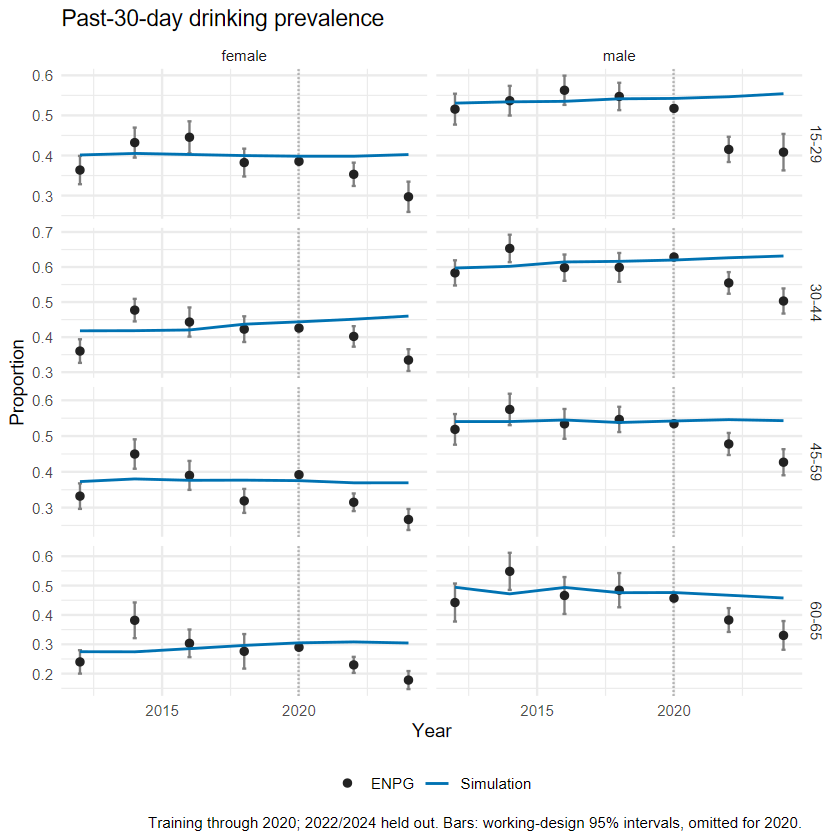

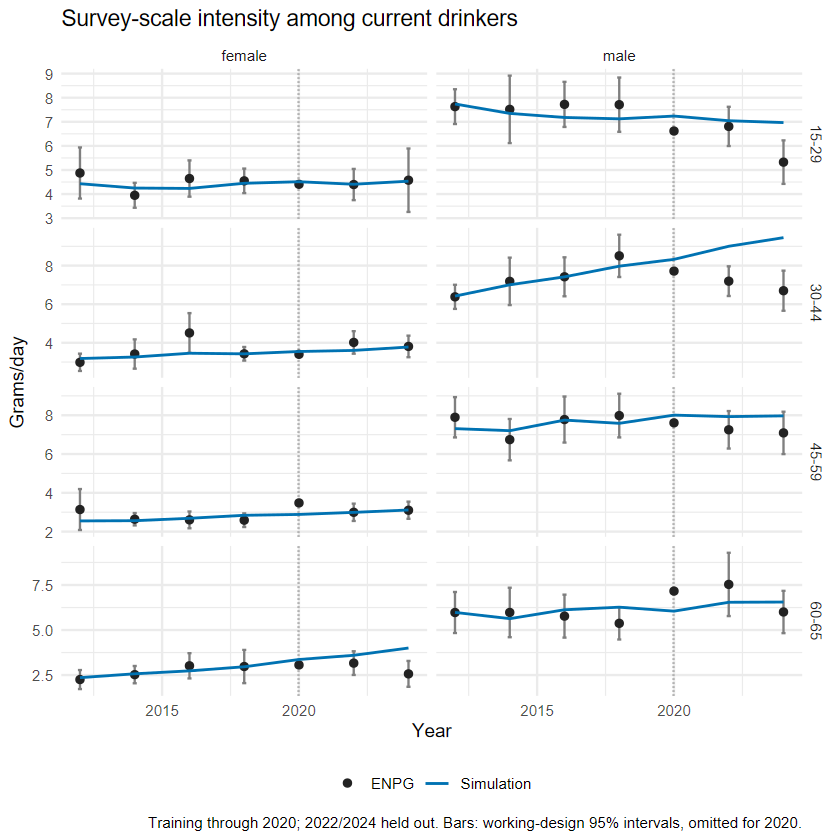

ms-comparison-figures elapsed minutes: 0.02



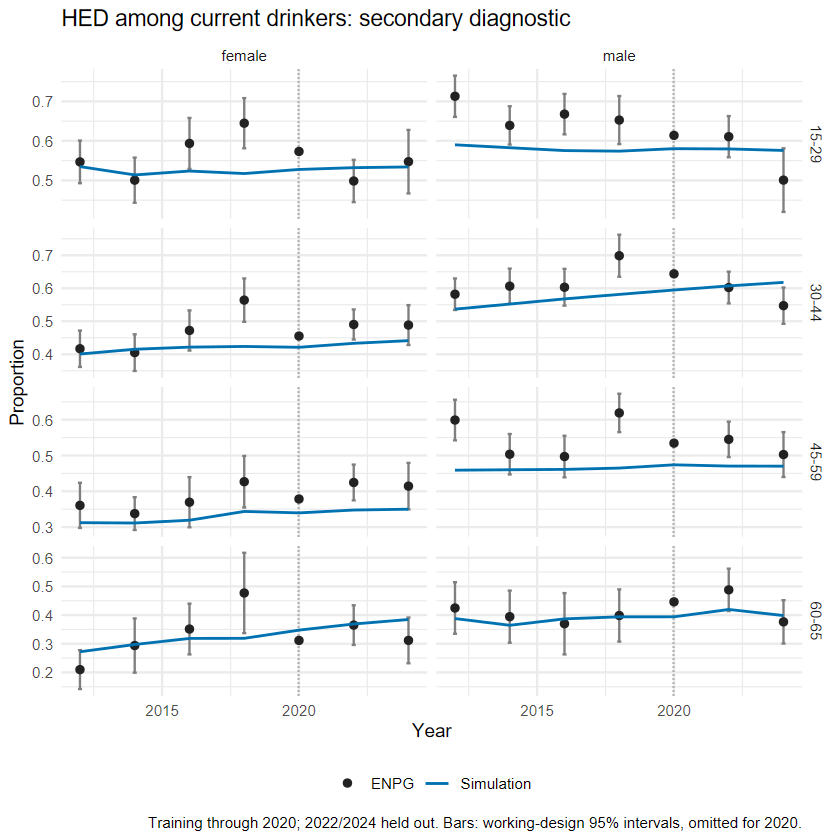

In [10]:
#| label: ms-comparison-figures
.t0 <- Sys.time()
ms_plot <- function(metric, title, y_label) {
  d <- ms_comparison[ms_comparison$metric == metric, ]
  d$age_band <- base::factor(d$age_group, levels = 1:4, labels = base::c("15-29", "30-44", "45-59", "60-65"))
  ggplot2::ggplot(d, ggplot2::aes(year)) +
    ggplot2::geom_vline(xintercept = 2020, linetype = 3, colour = "grey50") +
    ggplot2::geom_errorbar(ggplot2::aes(ymin = observed - 1.96 * se, ymax = observed + 1.96 * se),
      data = d[d$year != 2020L, ], width = 0.15, colour = "grey50") +
    ggplot2::geom_point(ggplot2::aes(y = observed, colour = "ENPG"), size = 1.6) +
    ggplot2::geom_line(ggplot2::aes(y = simulated, colour = "Simulation"), linewidth = 0.6) +
    ggplot2::facet_grid(age_band ~ sex, scales = "free_y") +
    ggplot2::scale_colour_manual(values = base::c(ENPG = "#222222", Simulation = "#0072B2")) +
    ggplot2::labs(title = title, x = "Year", y = y_label, colour = NULL,
      caption = "Training through 2020; 2022/2024 held out. Bars: working-design 95% intervals, omitted for 2020.") +
    ggplot2::theme_minimal(base_size = 11) + ggplot2::theme(legend.position = "bottom")
}
ms_fig_prevalence <- ms_plot("current", "Past-30-day drinking prevalence", "Proportion")
ms_fig_intensity <- ms_plot("gpd", "Survey-scale intensity among current drinkers", "Grams/day")
ms_fig_hed <- ms_plot("hed", "HED among current drinkers: secondary diagnostic", "Proportion")
base::print(ms_fig_prevalence)
base::print(ms_fig_intensity)
base::print(ms_fig_hed)
base::message(base::sprintf("ms-comparison-figures elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))


## 12. Persistence sensitivity

The same seed and demographic process are used for rho=0, the working value 0.8, and 0.95. Compare annual current-status changes and synthetic never/former prevalence as well as the marginal current prevalence. Large history differences with similar margins demonstrate the identification problem. All-cause mortality remains exposure-independent. No sensitivity value is declared biologically correct.

In [11]:
#| label: ms-persistence-sensitivity
.t0 <- Sys.time()
ms_sensitivity <- base::lapply(base::c(0, ms_cfg$rho, 0.95), function(rho) {
  run <- ms_simulate(ms_calibrated, 2012:2024, ms_cfg$n_sim, ms_cfg$seeds[1], rho)
  last <- run$summary[run$summary$year == 2024L, ]
  base::data.frame(rho = rho,
    annual_current_status_change = base::sum(run$flows$status_changes) / base::sum(run$flows$transition_n),
    current_2024 = stats::weighted.mean(last$current_mean, last$n),
    never_2024 = stats::weighted.mean(last$never, last$n),
    former_2024 = stats::weighted.mean(last$former, last$n),
    deaths_total = base::sum(run$deaths$deaths))
})
ms_sensitivity <- dplyr::bind_rows(ms_sensitivity)
ms_table(ms_sensitivity, "Persistence changes synthetic histories; it is not identified by marginal fit")
base::message(base::sprintf("ms-persistence-sensitivity elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))


rho,annual_current_status_change,current_2024,never_2024,former_2024,deaths_total
0.00,0.4821,0.4872,0.0125,0.5003,407137
0.80,0.1984,0.4834,0.0520,0.4646,407137
0.95,0.0983,0.4864,0.1123,0.4013,407137


ms-persistence-sensitivity elapsed minutes: 0.09



## 13. All-wave refit and conditional projection

Only after the frozen-model evaluation do we refit using all seven waves. From 2025 onward, exposure-driver values and HMD qx are frozen at 2024 while INE population stocks evolve. This is a clearly specified scenario, not an official alcohol forecast or a validated ten-year intervention projection. The historical refit is shown separately and must not replace the held-out evaluation. Its single-seed output has Monte Carlo noise.

In [12]:
#| label: ms-full-refit-projection
.t0 <- Sys.time()
# Refit AFTER evaluating the frozen training model. This run has no remaining holdout.
ms_full_model <- ms_fit(ms_cfg$observed_end, trend = TRUE)
ms_full_run <- ms_simulate(ms_full_model, ms_cfg$start_year:ms_cfg$end_year,
  ms_cfg$n_sim, ms_cfg$seeds[1], ms_cfg$rho)
ms_refit_comparison <- dplyr::inner_join(ms_targets, ms_full_run$summary,
  by = base::c("year", "sex", "age_group"), suffix = base::c("_observed", "_simulated"))
base::stopifnot(base::nrow(ms_refit_comparison) == 56L)
ms_refit_metrics <- base::do.call(base::rbind, base::lapply(base::c("current", "gpd", "hed"), function(m) {
  error <- ms_refit_comparison[[base::paste0(m, "_mean_simulated")]] -
    ms_refit_comparison[[base::paste0(m, "_mean_observed")]]
  base::data.frame(metric = m, cells = base::length(error), bias = base::mean(error),
    rmse = base::sqrt(base::mean(error^2)), interpretation = "In-sample all-wave refit; one seed")
}))
ms_table(ms_refit_metrics, "All-wave historical refit diagnostics; not held-out validation")
ms_projection <- ms_full_run$summary |>
  dplyr::group_by(year) |>
  dplyr::summarise(current_prevalence = stats::weighted.mean(current_mean, population),
    gpd_population = stats::weighted.mean(gpd_population, population),
    population = base::sum(population),
    .groups = "drop") |>
  dplyr::mutate(period = base::ifelse(year <= 2024, "Historical refit", "Conditional projection"))
ms_projection <- dplyr::left_join(ms_projection, ms_full_run$deaths |>
  dplyr::group_by(year) |>
  dplyr::summarise(expected_deaths = base::sum(expected_deaths),
    realized_deaths = base::sum(deaths), .groups = "drop"), by = "year")
ms_terminal <- utils::tail(ms_full_run$flows, 1)
base::stopifnot(base::nrow(ms_projection) == 23L, !base::anyNA(ms_projection),
  base::abs(base::sum(ms_full_run$deaths$deaths) -
    base::sum(ms_full_run$flows$deaths * ms_full_run$flows$unit_weight)) < 1e-6,
  ms_terminal$end_definition == "Terminal-year survivors",
  ms_terminal$age_exits + ms_terminal$age_entries + ms_terminal$residual_inflow +
    ms_terminal$residual_outflow == 0)
ms_table(ms_projection, "All-wave refit and frozen-2024 exposure/mortality scenario with INE projected stocks")
ms_table(ms_full_run$flows, "Person accounting: unweighted synthetic counts, constant expansion weight")
# A few synthetic IDs demonstrate paths; these are generated people, not survey participants.
ms_table(utils::head(ms_full_run$histories, 24), "Illustrative synthetic trajectories; not observed person histories")
base::message(base::sprintf("ms-full-refit-projection elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))


metric,cells,bias,rmse,interpretation
current,56,-0.0028,0.0435,In-sample all-wave refit; one seed
gpd,56,-0.1189,0.5408,In-sample all-wave refit; one seed
hed,56,-0.0498,0.0728,In-sample all-wave refit; one seed


year,current_prevalence,gpd_population,population,period,expected_deaths,realized_deaths
2012,0.4976,2.7837,12031236,Historical refit,27260.45,29837.47
2013,0.4880,2.7169,12175130,Historical refit,28248.52,30318.71
2014,0.4807,2.6510,12311804,Historical refit,28284.94,30318.71
2015,0.4753,2.6130,12442223,Historical refit,28903.18,28874.97
2016,0.4614,2.5721,12584673,Historical refit,28537.08,28393.72
2017,0.4560,2.5458,12768029,Historical refit,28506.22,25506.22
2018,0.4481,2.5183,12963897,Historical refit,28781.45,37056.21
2019,0.4393,2.4661,13168910,Historical refit,29744.40,26468.72
2020,0.4301,2.4548,13332534,Historical refit,34515.24,27912.47
2021,0.4215,2.3647,13414347,Historical refit,38664.18,40906.20


year,seed,start,deaths,age_exits,age_entries,residual_inflow,residual_outflow,end,status_changes,transition_n,unit_weight,end_definition
2012,20260917,25000,62,249,547,70,7,25299,4901,24682,481.2494,Next January stock
2013,20260917,25299,63,259,540,79,13,25583,4971,24964,481.2494,Next January stock
2014,20260917,25583,63,283,525,107,15,25854,5059,25222,481.2494,Next January stock
2015,20260917,25854,60,289,521,131,7,26150,5074,25498,481.2494,Next January stock
2016,20260917,26150,59,296,518,228,10,26531,5195,25785,481.2494,Next January stock
2017,20260917,26531,53,306,505,264,3,26938,5157,26169,481.2494,Next January stock
2018,20260917,26938,77,327,500,332,2,27364,5144,26532,481.2494,Next January stock
2019,20260917,27364,55,347,494,252,4,27704,5351,26958,481.2494,Next January stock
2020,20260917,27704,58,352,498,100,18,27874,5267,27276,481.2494,Next January stock
2021,20260917,27874,85,365,505,225,8,28146,5227,27416,481.2494,Next January stock


id,sex,age,ever,current,alc_status,gpd_survey,hed,year
1,female,15,TRUE,TRUE,current,3.0995,TRUE,2012
2,female,15,TRUE,FALSE,former,0.0000,FALSE,2012
3,female,15,TRUE,TRUE,current,3.1993,TRUE,2012
4,female,15,TRUE,TRUE,current,2.9943,FALSE,2012
5,female,15,TRUE,TRUE,current,7.7479,TRUE,2012
6,female,15,TRUE,TRUE,current,2.7524,FALSE,2012
7,female,15,FALSE,FALSE,never,0.0000,FALSE,2012
8,female,15,TRUE,TRUE,current,9.4350,TRUE,2012
9,female,15,TRUE,TRUE,current,33.7661,TRUE,2012
10,female,15,TRUE,FALSE,former,0.0000,FALSE,2012


ms-full-refit-projection elapsed minutes: 0.06



## 14. Parameter registry, provenance and aggregate exports

The registry distinguishes training-only coefficients from the all-wave refit, records structural assumptions, and exports Gamma/zero/history parameters separately. Input hashes identify the exact local vintages. Exports contain aggregate outcomes and source provenance; original survey microdata and existing artifacts are unchanged.

In [13]:
#| label: ms-export-parameters-and-audits
.t0 <- Sys.time()
ms_coefficients <- function(model, fit_name) {
  dplyr::bind_rows(base::lapply(base::c("prevalence", "amount", "hed"), function(component) {
    values <- stats::coef(model[[component]])
    base::data.frame(fit = fit_name, component = component, parameter = base::names(values),
      value = base::unname(values), source = "ENPG survey-weighted working calibration",
      last_fit_year = model$last_year)
  }), base::data.frame(fit = fit_name, component = "all_cause_mortality",
    parameter = base::names(model$mortality_scale), value = base::unname(model$mortality_scale),
    source = "HMD qx and DEIS training deaths", last_fit_year = model$last_year))
}
ms_parameters <- dplyr::bind_rows(ms_coefficients(ms_calibrated, "validation_train2020"),
  ms_coefficients(ms_full_model, "full_refit2024"))
ms_structural_parameters <- base::data.frame(parameter = base::c("rho", "minimum_age", "maximum_age", "n_sim",
  "replicates", "grams_per_drink", "forecast_driver_reference_year"),
  value = base::c(ms_cfg$rho, 15, 65, ms_cfg$n_sim, base::length(ms_cfg$seeds), 12, 2024),
  interpretation = base::c("Unidentified persistence; sensitivity 0 and 0.95",
    "Entry at age 15", "Exit at age 66; older-age benefits excluded", "Synthetic population scale",
    "Monte Carlo repeats, not parameter uncertainty", "Inherited survey measurement convention",
    "Exposure driver and HMD qx held at 2024 for 2025-2034"))
ms_table(ms_structural_parameters, "Structural assumptions to discuss with coauthors")
ms_all_sources <- base::unique(base::c(ms_exposure_files, ms_demography_files,
  "__andres_control/plan_trabajo_post_reunion_ACC_2026-09-17.md"))
ms_provenance <- base::data.frame(file = ms_all_sources,
  md5 = base::unname(tools::md5sum(ms_path(ms_all_sources))))
# SIMAH is cited by DOI (not vendored): its own row, without a file hash.
ms_provenance <- base::rbind(ms_provenance, base::data.frame(
  file = "SIMAH release 0.1.1, doi:10.5281/zenodo.15641639", md5 = NA_character_))
if (ms_cfg$export) {
  base::dir.create(here::here(ms_cfg$output_dir), recursive = TRUE, showWarnings = FALSE)
  ms_exports <- base::list(observed_targets = ms_targets, validation_metrics = ms_performance,
    validation_comparison = ms_comparison, mortality_concordance = ms_mortality_comparison,
    model_parameters = ms_parameters, structural_parameters = ms_structural_parameters,
    gamma_parameters_train2020 = ms_calibrated$shape, gamma_parameters_refit2024 = ms_full_model$shape,
    demographic_accounting = ms_full_run$flows, projection = ms_projection,
    projection_mortality = ms_full_run$deaths, static_comparator_metrics = ms_reference_performance,
    historical_refit_comparison = ms_refit_comparison, historical_refit_metrics = ms_refit_metrics,
    persistence_sensitivity = ms_sensitivity, input_provenance = ms_provenance, data_audit = ms_data_audit)
  for (name in base::names(ms_exports))
    utils::write.csv(ms_exports[[name]], here::here(ms_cfg$output_dir, base::paste0(name, ".csv")),
      row.names = FALSE, fileEncoding = "UTF-8")
  ggplot2::ggsave(here::here(ms_cfg$output_dir, "prevalence_validation.png"), ms_fig_prevalence,
    width = 9, height = 8, dpi = 160)
  ggplot2::ggsave(here::here(ms_cfg$output_dir, "intensity_validation.png"), ms_fig_intensity,
    width = 9, height = 8, dpi = 160)
  base::cat("Aggregate outputs saved to ", ms_cfg$output_dir, ". No survey microdata exported.\n", sep = "")
}
base::print(utils::sessionInfo())
base::message(base::sprintf("ms-export-parameters-and-audits elapsed minutes: %.2f",
  base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))


parameter,value,interpretation
rho,0.8,Unidentified persistence; sensitivity 0 and 0.95
minimum_age,15.0,Entry at age 15
maximum_age,65.0,Exit at age 66; older-age benefits excluded
n_sim,25000.0,Synthetic population scale
replicates,5.0,"Monte Carlo repeats, not parameter uncertainty"
grams_per_drink,12.0,Inherited survey measurement convention
forecast_driver_reference_year,2024.0,Exposure driver and HMD qx held at 2024 for 2025-2034


Aggregate outputs saved to __andres_control/microsim_base_outputs. No survey microdata exported.


R version 4.4.1 (2024-06-14 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default


locale:
[1] C
system code page: 65001

time zone: America/Santiago
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

loaded via a namespace (and not attached):
 [1] generics_0.1.4     lattice_0.22-6     hms_1.1.4          digest_0.6.37     
 [5] magrittr_2.0.3     RColorBrewer_1.1-3 evaluate_1.0.5     grid_4.4.1        
 [9] pbdZMQ_0.3-14      fastmap_1.2.0      cellranger_1.1.0   rprojroot_2.0.4   
[13] jsonlite_2.0.0     Matrix_1.7-0       DBI_1.2.3          survival_3.6-4    
[17] purrr_1.0.4        scales_1.4.0       textshaping_1.0.0  cli_3.6.4         
[21] mitools_2.4        rlang_1.1.5        crayon_1.5.3       bit64_4.6.0-1     
[25] splines_4.4.1      withr_3.0.2        base64enc_0.1-3    repr_1.1.7        
[29] tools_4.4.1        tzdb_0.4.0         uuid_1.2-1       

ms-export-parameters-and-audits elapsed minutes: 0.01



## 15. Interpretation and decisions before extending the model

This notebook supplies an executable base and exposes what can and cannot be inferred. **The default model fails the held-out prevalence evaluation**; it is not ready to claim calibrated natural-history reproduction. Investigate measurement, trend specification, missingness and distributional shape before adopting it. Once 2022/2024 informs a revision, those waves become development data; the same comparison cannot remain an untouched holdout.

Persistence sensitivity reinforces the limit: rho=0, 0.8 and 0.95 produce similar 2024 current prevalence (about 48–49%) but very different never-drinker histories (about 1.25%, 5.20% and 11.23%). These histories are unvalidated. Expected 2024 all-cause deaths exceed DEIS by about 5.17% in men and 3.22% in women; keep this discrepancy separate from simulated-death noise. The projection includes both expected and realized deaths, with exposure-independent survival.

| Project module | Implemented here | Required before claiming a completed alcohol-policy model |
| :--- | :--- | :--- |
| Mortality | All-cause annual deaths, HMD/DEIS concordance, train-only scaling | Consumption-dependent cause-specific hazards and competing-risk validation; reconcile cached YPLL; retain distinct YLL/YPLL estimands |
| Policy counterfactuals | Baseline only | Explicit intervention mechanism, eligibility/coverage, latency, AAF=1 handling and matched cause support; total deaths × PIF, not attributable deaths × PIF |
| Elasticity | Deferred | Beverage assignment and verified elasticities; distinguish intensive purchasing margin from participation; do not equate EPF purchase participation with drinking initiation |
| Simulation | Population, age, annual exposure process, deaths, flows, calibration and evaluation | Validate longitudinal persistence and former history, address ages above 65, improve design/missingness and inspect exposure tails |
| Integration | Common person-year exposure and mortality records | Connect the authorized RR sources and intervention-updated exposure to individual hazards without double counting |

For later price policies, retain the project sequence: beverage-specific use → participation response if included → beverage-specific elasticity → continuous consumption → category recoding. No beverage shares are fabricated now. For socioeconomic stratification, education can improve distributional analysis but adds sparse cells, selection/measurement issues and transition parameters. Begin with a documented precision and missingness audit before adopting three education strata; income and education are not interchangeable.

**Pending scientific choices for ACC/coauthors:** defensible individual persistence, treatment of 2020, the survey-to-APC bridge, the older-age domain, and the cause-specific mortality link. Monte Carlo replication alone does not cover these uncertainties. The updated parameter tables and validation results provide concrete material for that discussion.

The Spanish companion [implementation explanation](microsim_base_ACC_2012_2024_explicacion.md) reports actual execution findings and a short next-action list. The [canonical handoff](codex_handoff_adam_rr_full_override_caveman.md) records the audits without replacing earlier entries.